# Faza 4 — Scalare la Modele Mai Mari + FP8 Native
## ViT-Tiny / ViT-Small / ViT-Base pe ImageNet-1k · NVIDIA A100
### Tudose Alexandru · Lucrare de Licență 2026

**Ce rulează acest notebook:**
1. FP32 / FP16 / INT8-pt / INT8-pc pe ViT-Tiny, ViT-Small, ViT-Base
2. FP8 E4M3FN (per-tensor + per-channel) pe toate trei modelele
3. Comparație cross-model cu ploturi

## 0. Verificare GPU

In [1]:
import torch
print(torch.cuda.get_device_name(0))
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
cap = torch.cuda.get_device_capability()
print(f"Compute capability: {cap[0]}.{cap[1]}")
if cap[0] >= 9:
    print("→ Hopper: hardware FP8 GEMM disponibil")
elif cap[0] >= 8:
    print("→ Ampere: FP8 dtype suportat, fara hardware FP8 GEMM")
print(f"FP8 (float8_e4m3fn) available: {hasattr(torch, 'float8_e4m3fn')}")

NVIDIA A100-SXM4-80GB
CUDA: 12.8
PyTorch: 2.10.0+cu128
VRAM: 85.1 GB
Compute capability: 8.0
→ Ampere: FP8 dtype suportat, fara hardware FP8 GEMM
FP8 (float8_e4m3fn) available: True


## 1. Setup — Drive, Repo, Dependente

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Chewdoughsay/ViT-FP8-experiments.git
%cd ViT-FP8-experiments

Mounted at /content/drive
Cloning into 'ViT-FP8-experiments'...
remote: Enumerating objects: 348, done.
remote: Counting objects: 100% (348/348), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 348 (delta 158), reused 290 (delta 100), pack-reused 0 (from 0)
Receiving objects: 100% (348/348), 12.70 MiB | 10.57 MiB/s, done.
Resolving deltas: 100% (158/158), done.
/content/ViT-FP8-experiments


In [3]:
!pip install -q timm datasets huggingface_hub

## 2. Copiere ImageNet de pe Drive

In [ ]:
import shutil, os

os.makedirs('data/imagenet-1k', exist_ok=True)
shutil.copytree(
    '/content/drive/MyDrive/imagenet-1k',
    'data/imagenet-1k',
    dirs_exist_ok=True
)
print("Dataset copiat OK")
!ls data/imagenet-1k/

Dataset copiat OK
validation-00000-of-00014.parquet  validation-00007-of-00014.parquet
validation-00001-of-00014.parquet  validation-00008-of-00014.parquet
validation-00002-of-00014.parquet  validation-00009-of-00014.parquet
validation-00003-of-00014.parquet  validation-00010-of-00014.parquet
validation-00004-of-00014.parquet  validation-00011-of-00014.parquet
validation-00005-of-00014.parquet  validation-00012-of-00014.parquet
validation-00006-of-00014.parquet  validation-00013-of-00014.parquet


## 3. Sanity check

In [ ]:
import sys
sys.path.insert(0, '/content/ViT-FP8-experiments')

import timm, timm.data, torch
from src.models.quantized_linear import quantize_model_selective

model = timm.create_model('vit_tiny_patch16_224', pretrained=True).cuda().eval()
model, stats = quantize_model_selective(model, verbose=False)
x = torch.randn(4, 3, 224, 224).cuda()
with torch.no_grad():
    out = model(x)
print(f"Forward pass OK — {out.shape}")
del model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Forward pass OK — torch.Size([4, 1000])


## 4. Evaluare FP32 / FP16 / INT8-pt / INT8-pc

In [ ]:
!python scripts/phase4/evaluate_model.py \
    --model vit_tiny_patch16_224 \
    --batch-size 128

Phase 4 — vit_tiny_patch16_224  (5.7M params)
PyTorch 2.10.0+cu128  |  device: cuda

Loading model...
  Data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
Generating train split: 50000 examples [00:16, 3061.84 examples/s]
  50,000 images


STEP 1: FP32 baseline
  Memory: 21.81 MB
FP32: 100% 391/391 [01:40<00:00,  3.88it/s]
  Accuracy: 75.454%  |  Latency: 28.358 ms/batch

STEP 2: FP16 (model.half())
  Memory: 10.905 MB  (reduction: 2.00x)
FP16: 100% 391/391 [01:42<00:00,  3.82it/s]
  Accuracy: 75.458%  |  Latency: 8.991 ms/batch

STEP 3: INT8 per-tensor
  Memory: 6.623 MB  (reduction: 3.29x)
INT8-pt: 100% 391/391 [01:39<00:00,  3.94it/s]
  Accuracy: 75.128%  |  Avg MSE: 2.88e-06

STEP 4: INT8 per-channel
INT8-pc: 100% 391/391 [01:40<00:00,  3.89it/s]
  Accuracy: 75.418%  |  Memory: 6.702 MB

SUMMAR

In [ ]:
!python scripts/phase4/evaluate_model.py \
    --model vit_small_patch16_224 \
    --batch-size 128

Phase 4 — vit_small_patch16_224  (22M params)
PyTorch 2.10.0+cu128  |  device: cuda

Loading model...
model.safetensors: 100% 88.2M/88.2M [00:02<00:00, 36.4MB/s]
  Data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
  50,000 images


STEP 1: FP32 baseline
  Memory: 84.117 MB
FP32: 100% 391/391 [01:41<00:00,  3.85it/s]
  Accuracy: 81.382%  |  Latency: 72.947 ms/batch

STEP 2: FP16 (model.half())
  Memory: 42.058 MB  (reduction: 2.00x)
FP16: 100% 391/391 [01:43<00:00,  3.79it/s]
  Accuracy: 81.394%  |  Latency: 15.391 ms/batch

STEP 3: INT8 per-tensor
  Memory: 23.367 MB  (reduction: 3.60x)
INT8-pt: 100% 391/391 [01:41<00:00,  3.87it/s]
  Accuracy: 81.296%  |  Avg MSE: 3.08e-06

STEP 4: INT8 per-channel
INT8-pc: 100% 391/391 [01:41<00:00,  3.85it/s]
  Accuracy: 81.396%  |  Memory: 23.525 MB

SUMMARY
M

In [ ]:
!python scripts/phase4/evaluate_model.py \
    --model vit_base_patch16_224 \
    --batch-size 64

Phase 4 — vit_base_patch16_224  (86M params)
PyTorch 2.10.0+cu128  |  device: cuda

Loading model...
model.safetensors: 100% 346M/346M [00:04<00:00, 82.0MB/s]
  Data config: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
  50,000 images


STEP 1: FP32 baseline
  Memory: 330.229 MB
FP32: 100% 782/782 [01:45<00:00,  7.43it/s]
  Accuracy: 85.102%  |  Latency: 128.578 ms/batch

STEP 2: FP16 (model.half())
  Memory: 165.115 MB  (reduction: 2.00x)
FP16: 100% 782/782 [01:43<00:00,  7.58it/s]
  Accuracy: 85.11%  |  Latency: 18.3 ms/batch

STEP 3: INT8 per-tensor
  Memory: 87.229 MB  (reduction: 3.79x)
INT8-pt: 100% 782/782 [01:45<00:00,  7.43it/s]
  Accuracy: 85.08%  |  Avg MSE: 1.34e-06

STEP 4: INT8 per-channel
INT8-pc: 100% 782/782 [01:45<00:00,  7.41it/s]
  Accuracy: 85.1%  |  Memory: 87.546 MB

SUMMARY
Method 

In [ ]:
import shutil
shutil.copytree(
    '/content/ViT-FP8-experiments/results/Phase4',
    '/content/drive/MyDrive/vit_experiments/results/Phase4',
    dirs_exist_ok=True
)
print("Rezultate INT8 salvate pe Drive!")

Rezultate INT8 salvate pe Drive!


## 5. FP8 Native (float8_e4m3fn)

Rulează FP32 + INT8-pt + INT8-pc + **FP8-pt + FP8-pc** pe fiecare model.

Pe A100 (Ampere, compute capability 8.0): `float8_e4m3fn` este suportat ca dtype PyTorch,
dar fara hardware FP8 GEMM nativ (necesita H100 Hopper). Comparatia de acuratete este valida;
latenta FP8 nu reflecta potentialul hardware real.

In [ ]:
!python scripts/phase4/evaluate_fp8_native.py \
    --model vit_tiny_patch16_224 \
    --batch-size 128

Phase 4 — FP8 Native Evaluation — vit_tiny_patch16_224
PyTorch 2.10.0+cu128  |  device: cuda
FP8 (float8_e4m3fn) available: True
GPU: NVIDIA A100-SXM4-80GB  |  Compute capability: 8.0
  → Ampere GPU: FP8 dtype supported, partial acceleration

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
  50,000 images


FP32: FP32 baseline
FP32: 100% 391/391 [01:39<00:00,  3.93it/s]
  Accuracy: 75.454%  |  Latency: 29.845 ms  |  Memory: 21.81 MB

INT8-pt: INT8 per-tensor
INT8-pt: 100% 391/391 [01:39<00:00,  3.94it/s]
  Accuracy: 75.128%  |  Latency: 30.262 ms  |  Memory: 6.623 MB

INT8-pc: INT8 per-channel
INT8-pc: 100% 391/391 [01:39<00:00,  3.91it/s]
  Accuracy: 75.418%  |  Latency: 29.873 ms  |  Memory: 6.702 MB

FP8-pt: FP8 per-tensor
FP8-pt: 100% 391/391 [01:40<00:00,  3.90it/s]
  Accuracy: 75.258%  |  Latency: 30.063 ms  |  Memory: 6.623 MB

FP8-pc: FP8 per-channel
FP8-pc: 100% 391/391 [01:38<00:00,  3.95it/s]
  Accuracy: 75.352%  |  Latency: 29.536 ms  |  Mem

In [ ]:
!python scripts/phase4/evaluate_fp8_native.py \
    --model vit_small_patch16_224 \
    --batch-size 128

Phase 4 — FP8 Native Evaluation — vit_small_patch16_224
PyTorch 2.10.0+cu128  |  device: cuda
FP8 (float8_e4m3fn) available: True
GPU: NVIDIA A100-SXM4-80GB  |  Compute capability: 8.0
  → Ampere GPU: FP8 dtype supported, partial acceleration

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
  50,000 images


FP32: FP32 baseline
FP32: 100% 391/391 [01:40<00:00,  3.89it/s]
  Accuracy: 81.382%  |  Latency: 72.947 ms  |  Memory: 84.117 MB

INT8-pt: INT8 per-tensor
INT8-pt: 100% 391/391 [01:39<00:00,  3.93it/s]
  Accuracy: 81.296%  |  Latency: 73.346 ms  |  Memory: 23.367 MB

INT8-pc: INT8 per-channel
INT8-pc: 100% 391/391 [01:38<00:00,  3.96it/s]
  Accuracy: 81.396%  |  Latency: 73.381 ms  |  Memory: 23.525 MB

FP8-pt: FP8 per-tensor
FP8-pt: 100% 391/391 [01:40<00:00,  3.89it/s]
  Accuracy: 81.374%  |  Latency: 73.292 ms  |  Memory: 23.367 MB

FP8-pc: FP8 per-channel
FP8-pc: 100% 391/391 [01:40<00:00,  3.88it/s]
  Accuracy: 81.306%  |  Latency: 73.304 ms  |

In [ ]:
!python scripts/phase4/evaluate_fp8_native.py \
    --model vit_base_patch16_224 \
    --batch-size 64

Phase 4 — FP8 Native Evaluation — vit_base_patch16_224
PyTorch 2.10.0+cu128  |  device: cuda
FP8 (float8_e4m3fn) available: True
GPU: NVIDIA A100-SXM4-80GB  |  Compute capability: 8.0
  → Ampere GPU: FP8 dtype supported, partial acceleration

Loading ImageNet-1k validation...
  Loading from local parquet: data/imagenet-1k
  50,000 images


FP32: FP32 baseline
FP32: 100% 782/782 [01:45<00:00,  7.42it/s]
  Accuracy: 85.102%  |  Latency: 128.604 ms  |  Memory: 330.229 MB

INT8-pt: INT8 per-tensor
INT8-pt: 100% 782/782 [01:45<00:00,  7.41it/s]
  Accuracy: 85.08%  |  Latency: 129.77 ms  |  Memory: 87.229 MB

INT8-pc: INT8 per-channel
INT8-pc: 100% 782/782 [01:45<00:00,  7.40it/s]
  Accuracy: 85.1%  |  Latency: 129.988 ms  |  Memory: 87.546 MB

FP8-pt: FP8 per-tensor
FP8-pt: 100% 782/782 [01:45<00:00,  7.39it/s]
  Accuracy: 85.046%  |  Latency: 129.942 ms  |  Memory: 87.23 MB

FP8-pc: FP8 per-channel
FP8-pc: 100% 782/782 [01:45<00:00,  7.39it/s]
  Accuracy: 85.094%  |  Latency: 130.163 ms  |

In [ ]:
import shutil
shutil.copytree(
    '/content/ViT-FP8-experiments/results/Phase4',
    '/content/drive/MyDrive/vit_experiments/results/Phase4',
    dirs_exist_ok=True
)
print("Rezultate FP8 salvate pe Drive!")

Rezultate FP8 salvate pe Drive!


## 6. Comparatie cross-model

In [6]:
import shutil, os
from pathlib import Path

src = Path('/content/drive/MyDrive/vit_experiments/results/Phase4')
dst = Path('/content/ViT-FP8-experiments/results/Phase4')

dst.mkdir(parents=True, exist_ok=True)
shutil.copytree(src, dst, dirs_exist_ok=True)

# Verificare
jsons = list(dst.rglob('*.json'))
print(f"Copiat OK — {len(jsons)} fișiere JSON găsite:")
for j in sorted(jsons):
    print(f"  {j.relative_to(dst)}")

Copiat OK — 6 fișiere JSON găsite:
  vit_base_patch16_224/fp8_native/metrics/fp8_results.json
  vit_base_patch16_224/metrics/results.json
  vit_small_patch16_224/fp8_native/metrics/fp8_results.json
  vit_small_patch16_224/metrics/results.json
  vit_tiny_patch16_224/fp8_native/metrics/fp8_results.json
  vit_tiny_patch16_224/metrics/results.json


In [7]:
!python scripts/phase4/compare_cross_model.py

Loading results...
Loaded 3 model(s): ['vit_tiny_patch16_224', 'vit_small_patch16_224', 'vit_base_patch16_224']

Generating plots...
  Saved: 00_accuracy_cross_model.png
  Saved: 01_degradation_heatmap.png
  Saved: 02_memory_scaling.png
  Saved: 03_latency_scaling.png
  Saved: 04_hardware_comparison.png
  Saved: 05_fp16_speedup_scaling.png
  Saved: 06_int8_degradation_scaling.png
  Saved: results/Phase4/cross_model_comparison/summary.md

All outputs saved to results/Phase4/cross_model_comparison



--- 00_accuracy_cross_model.png ---


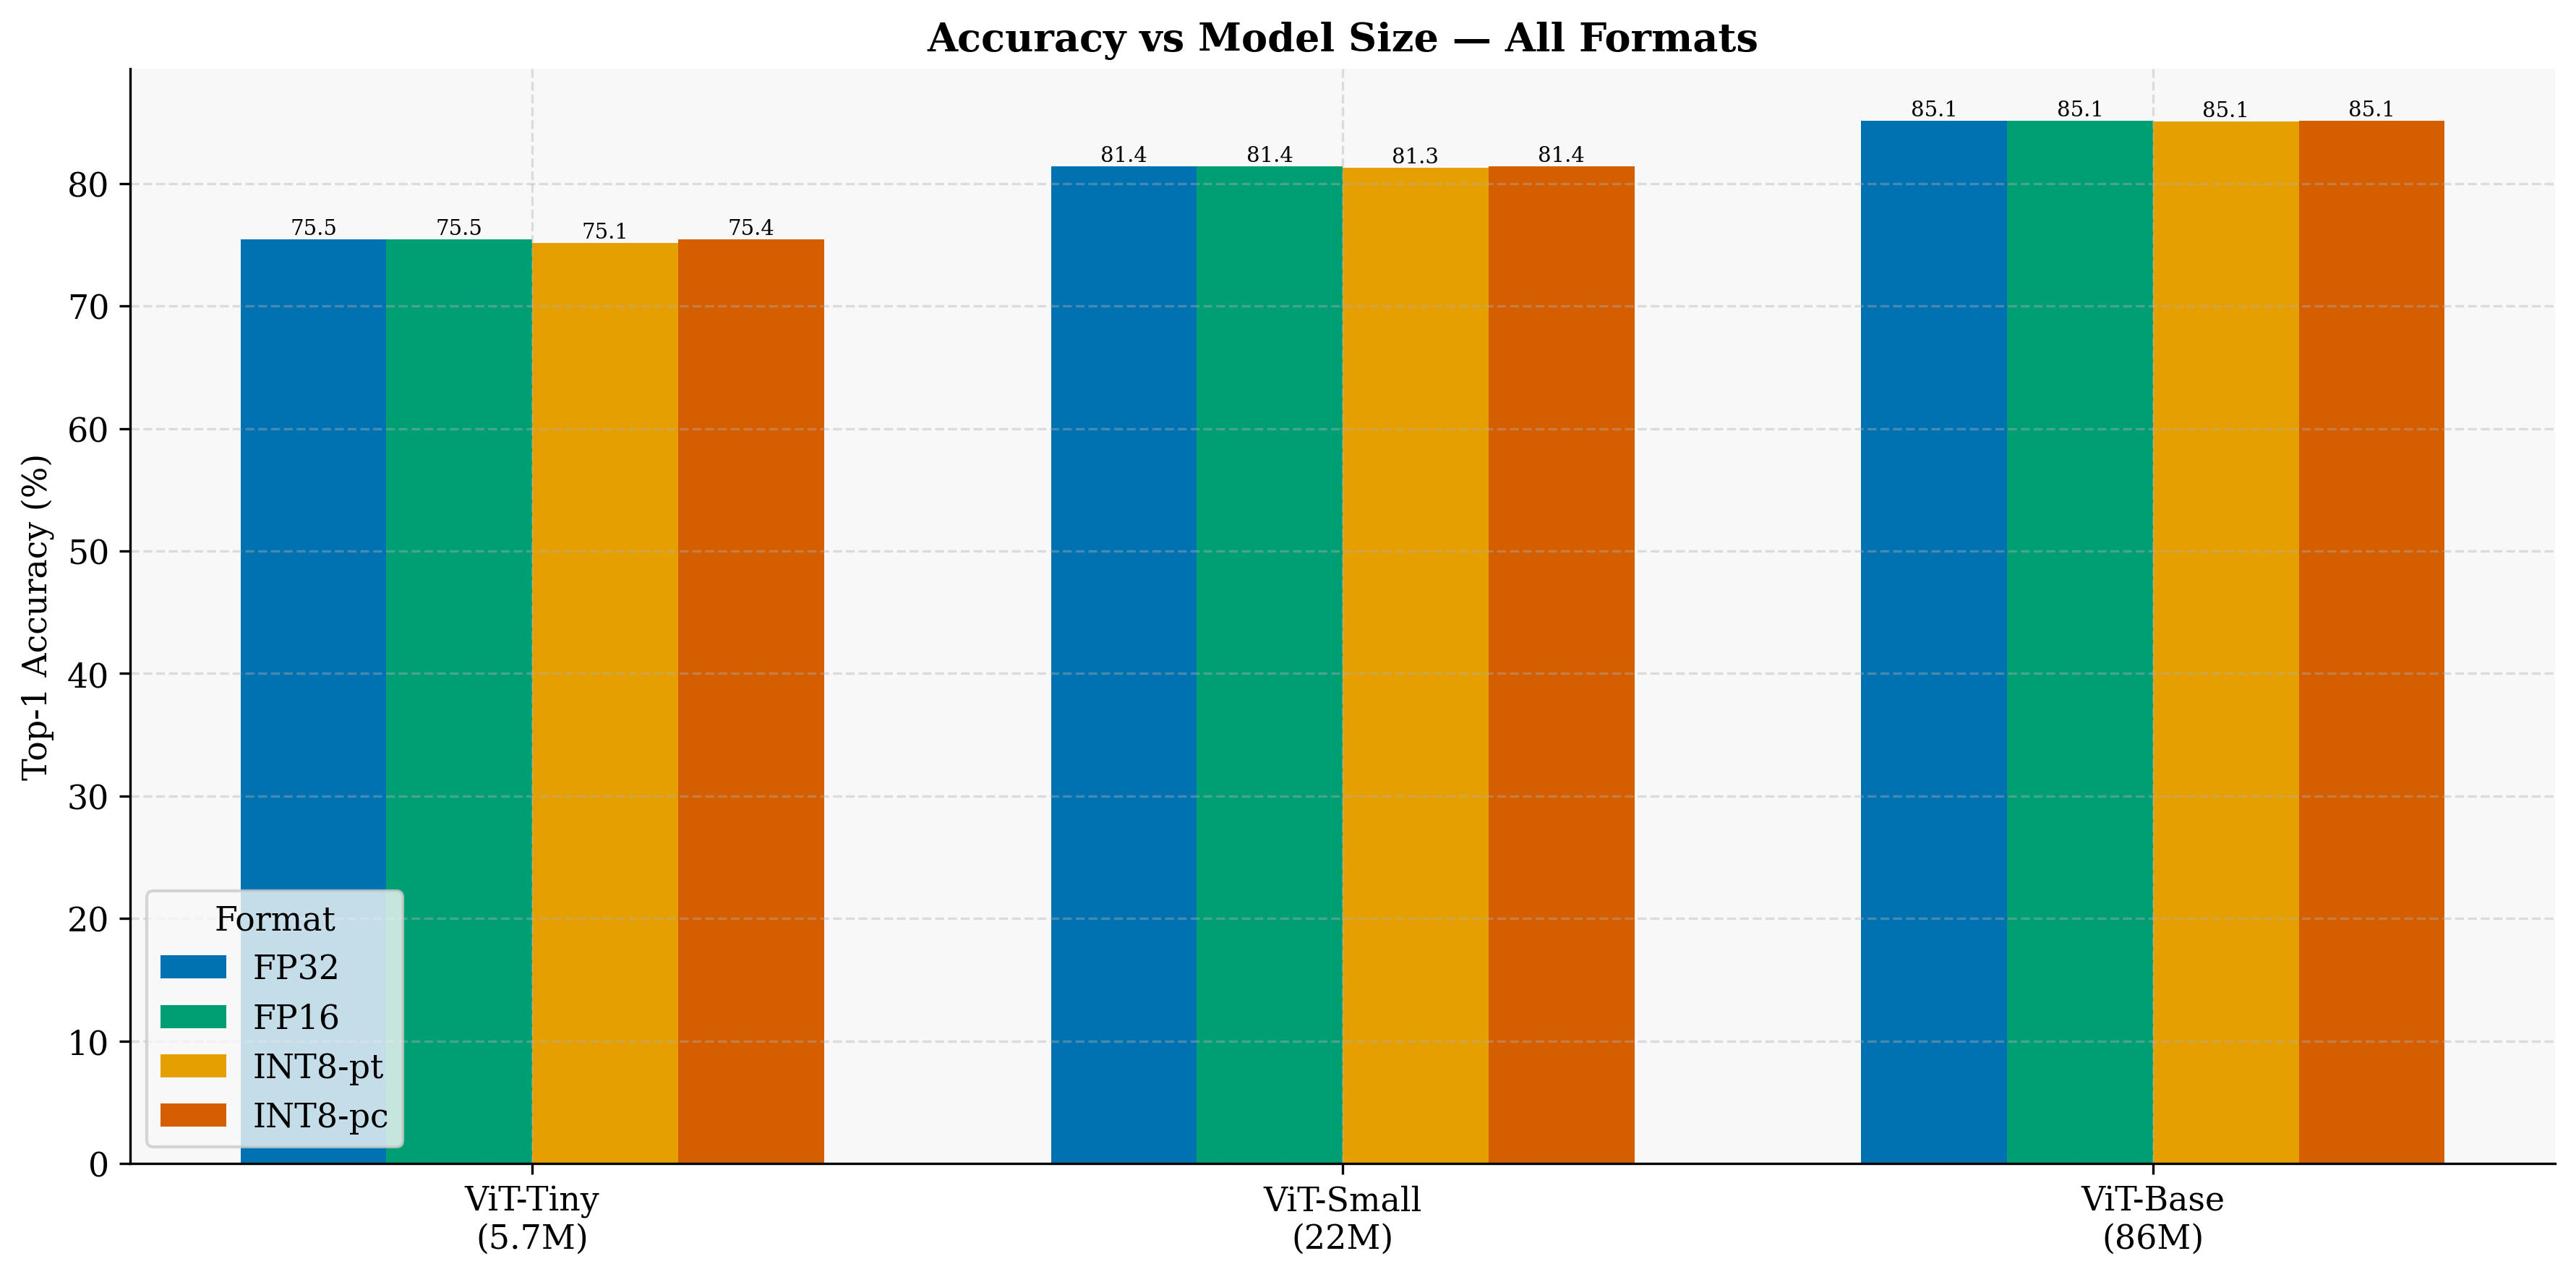


--- 01_degradation_heatmap.png ---


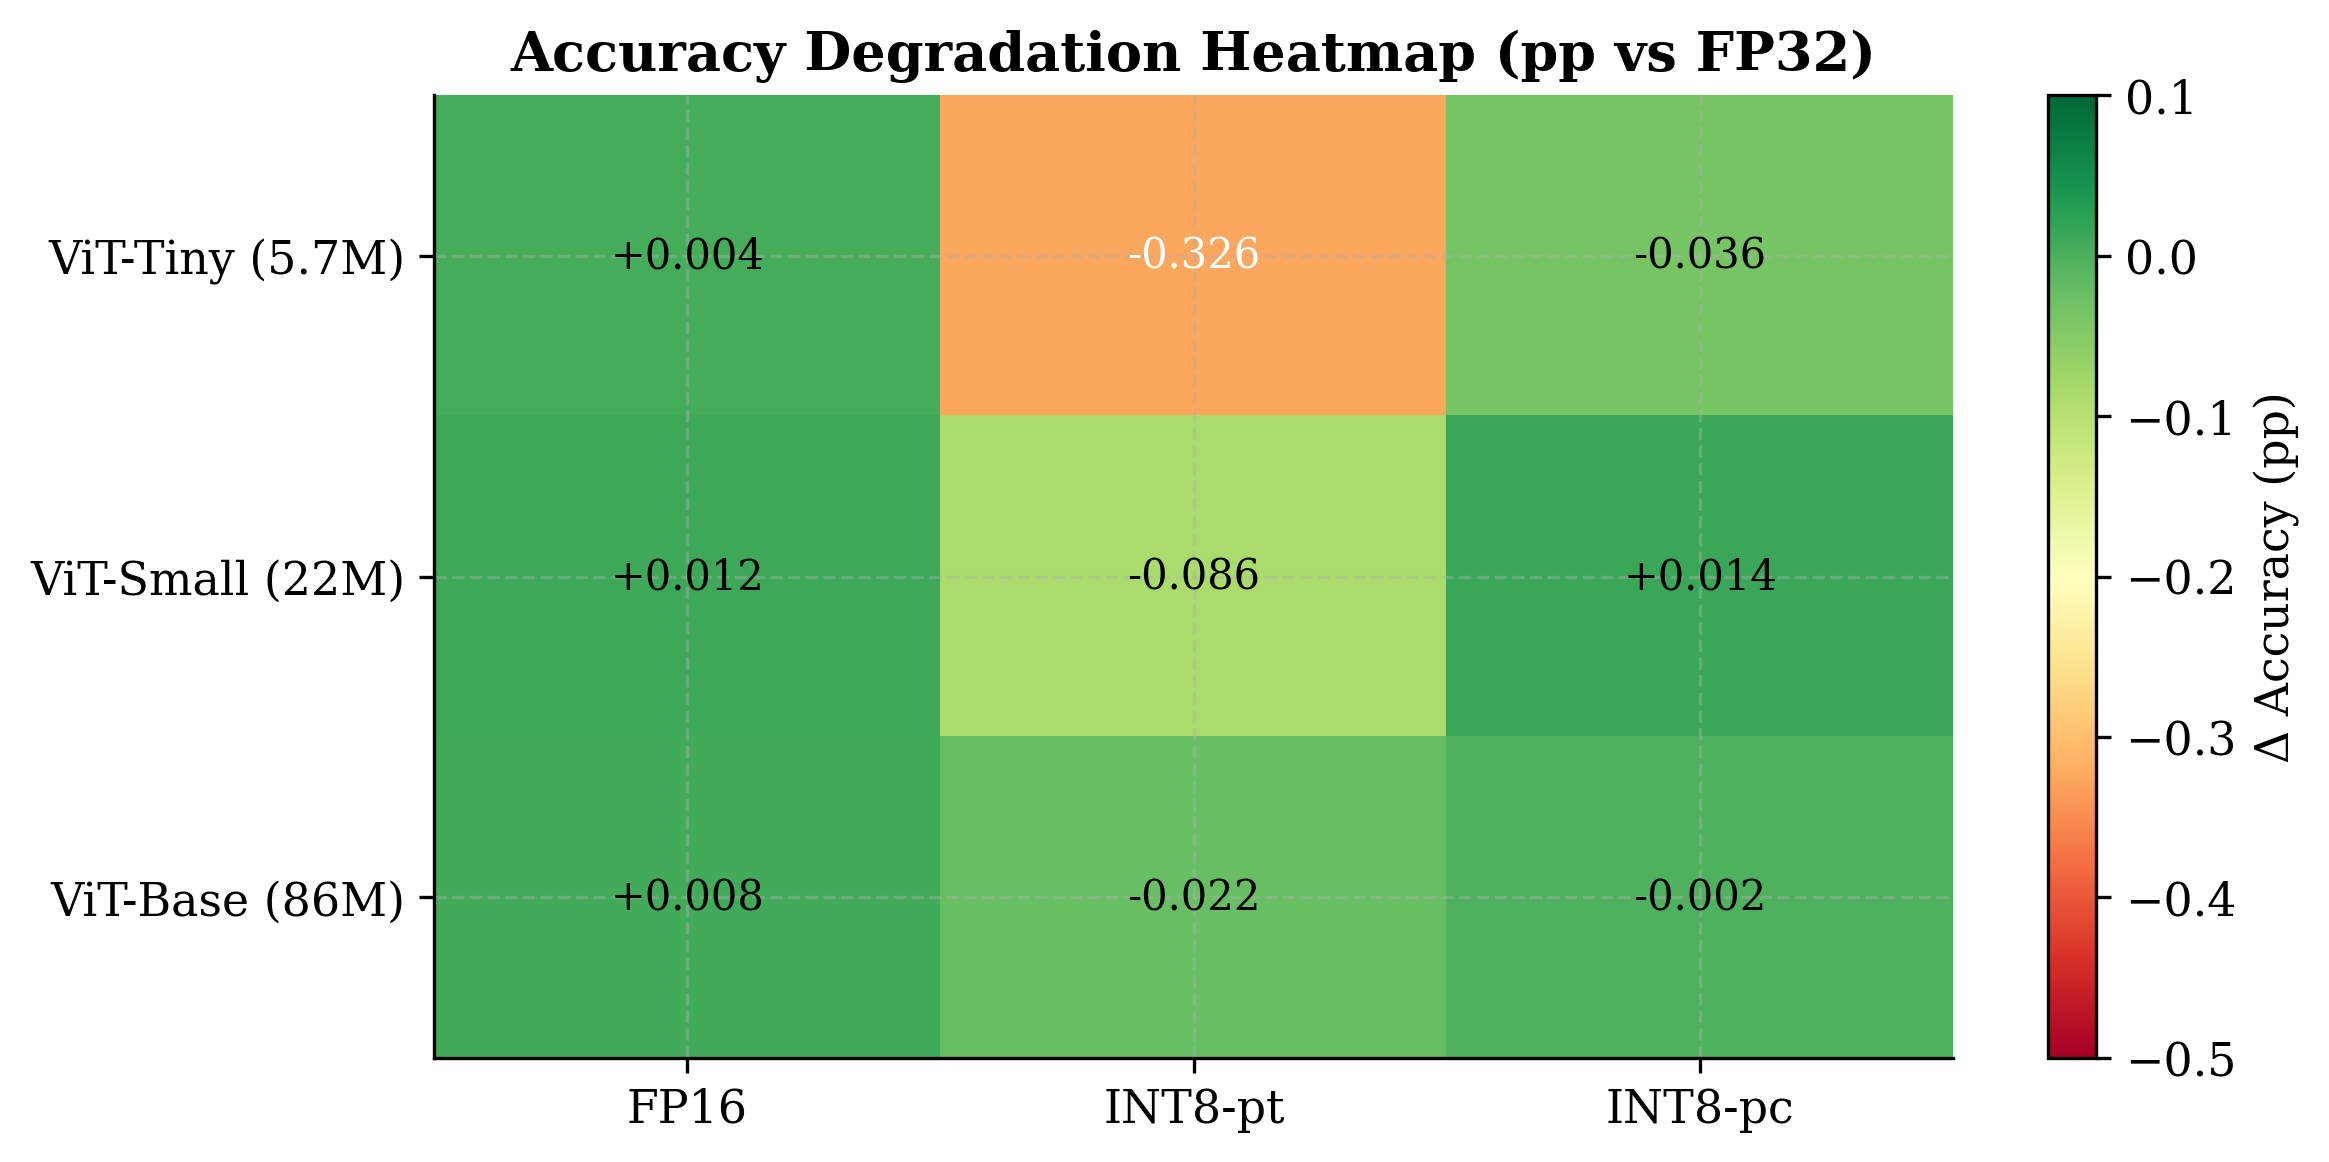


--- 02_memory_scaling.png ---


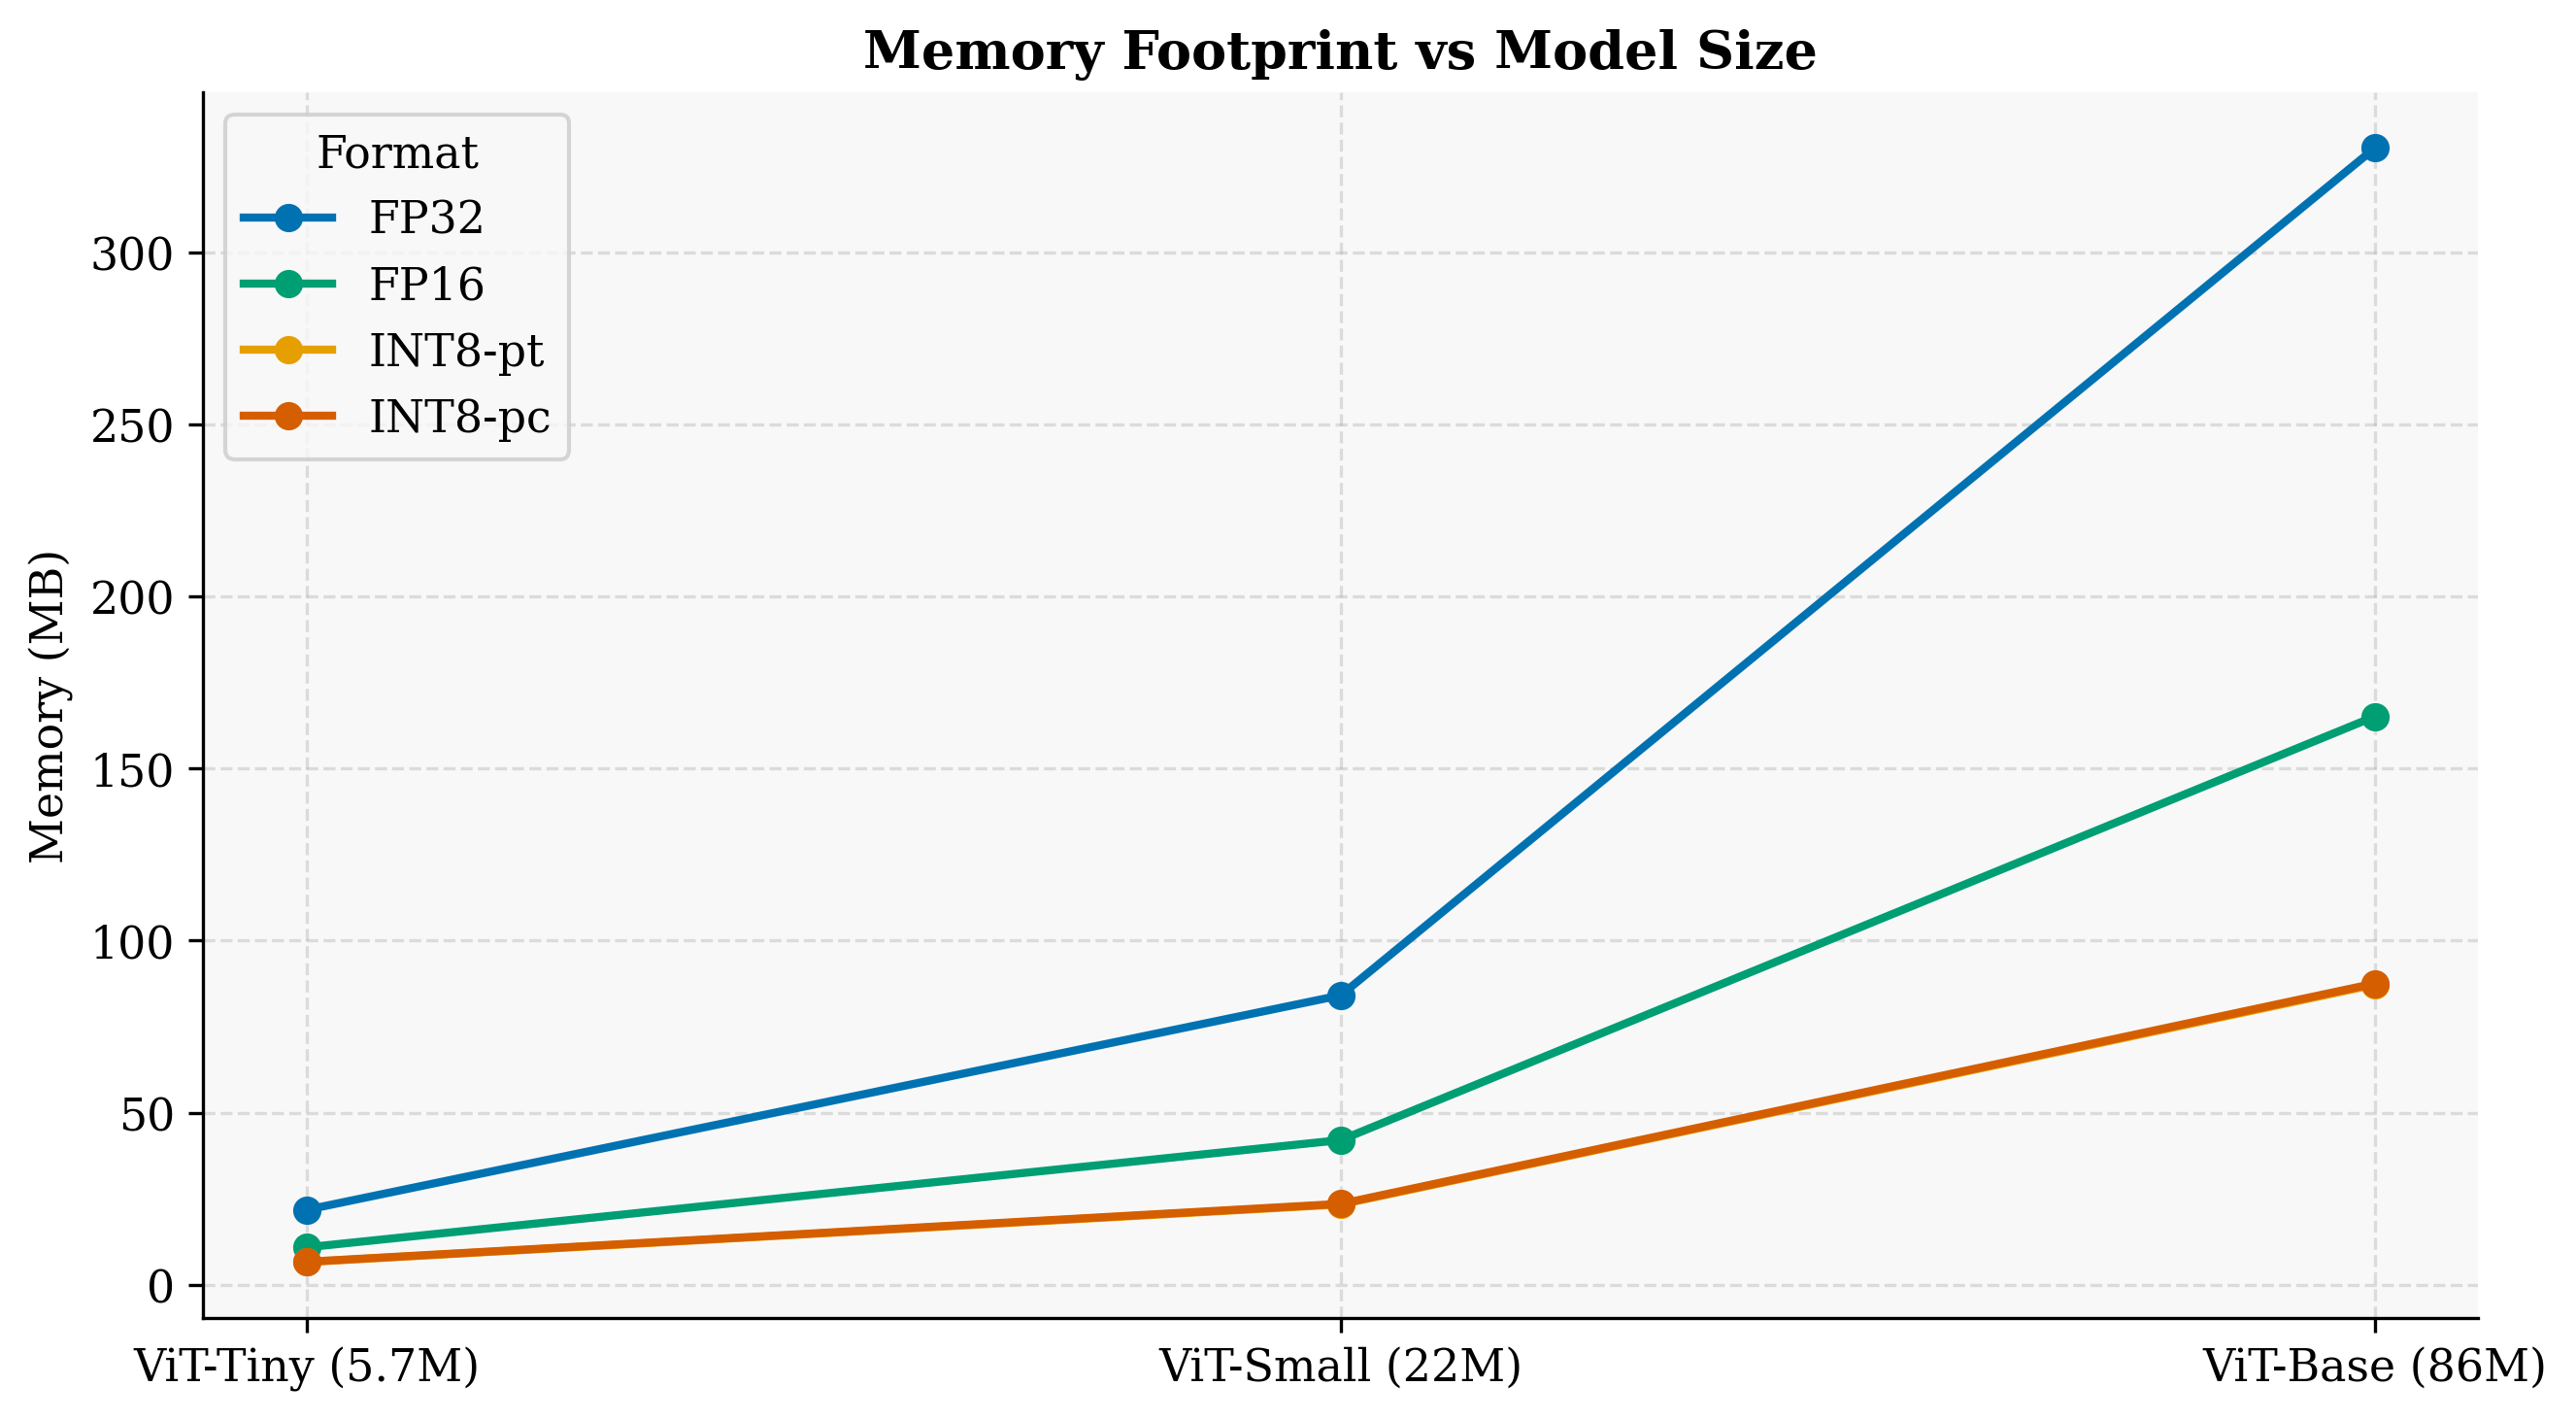


--- 03_latency_scaling.png ---


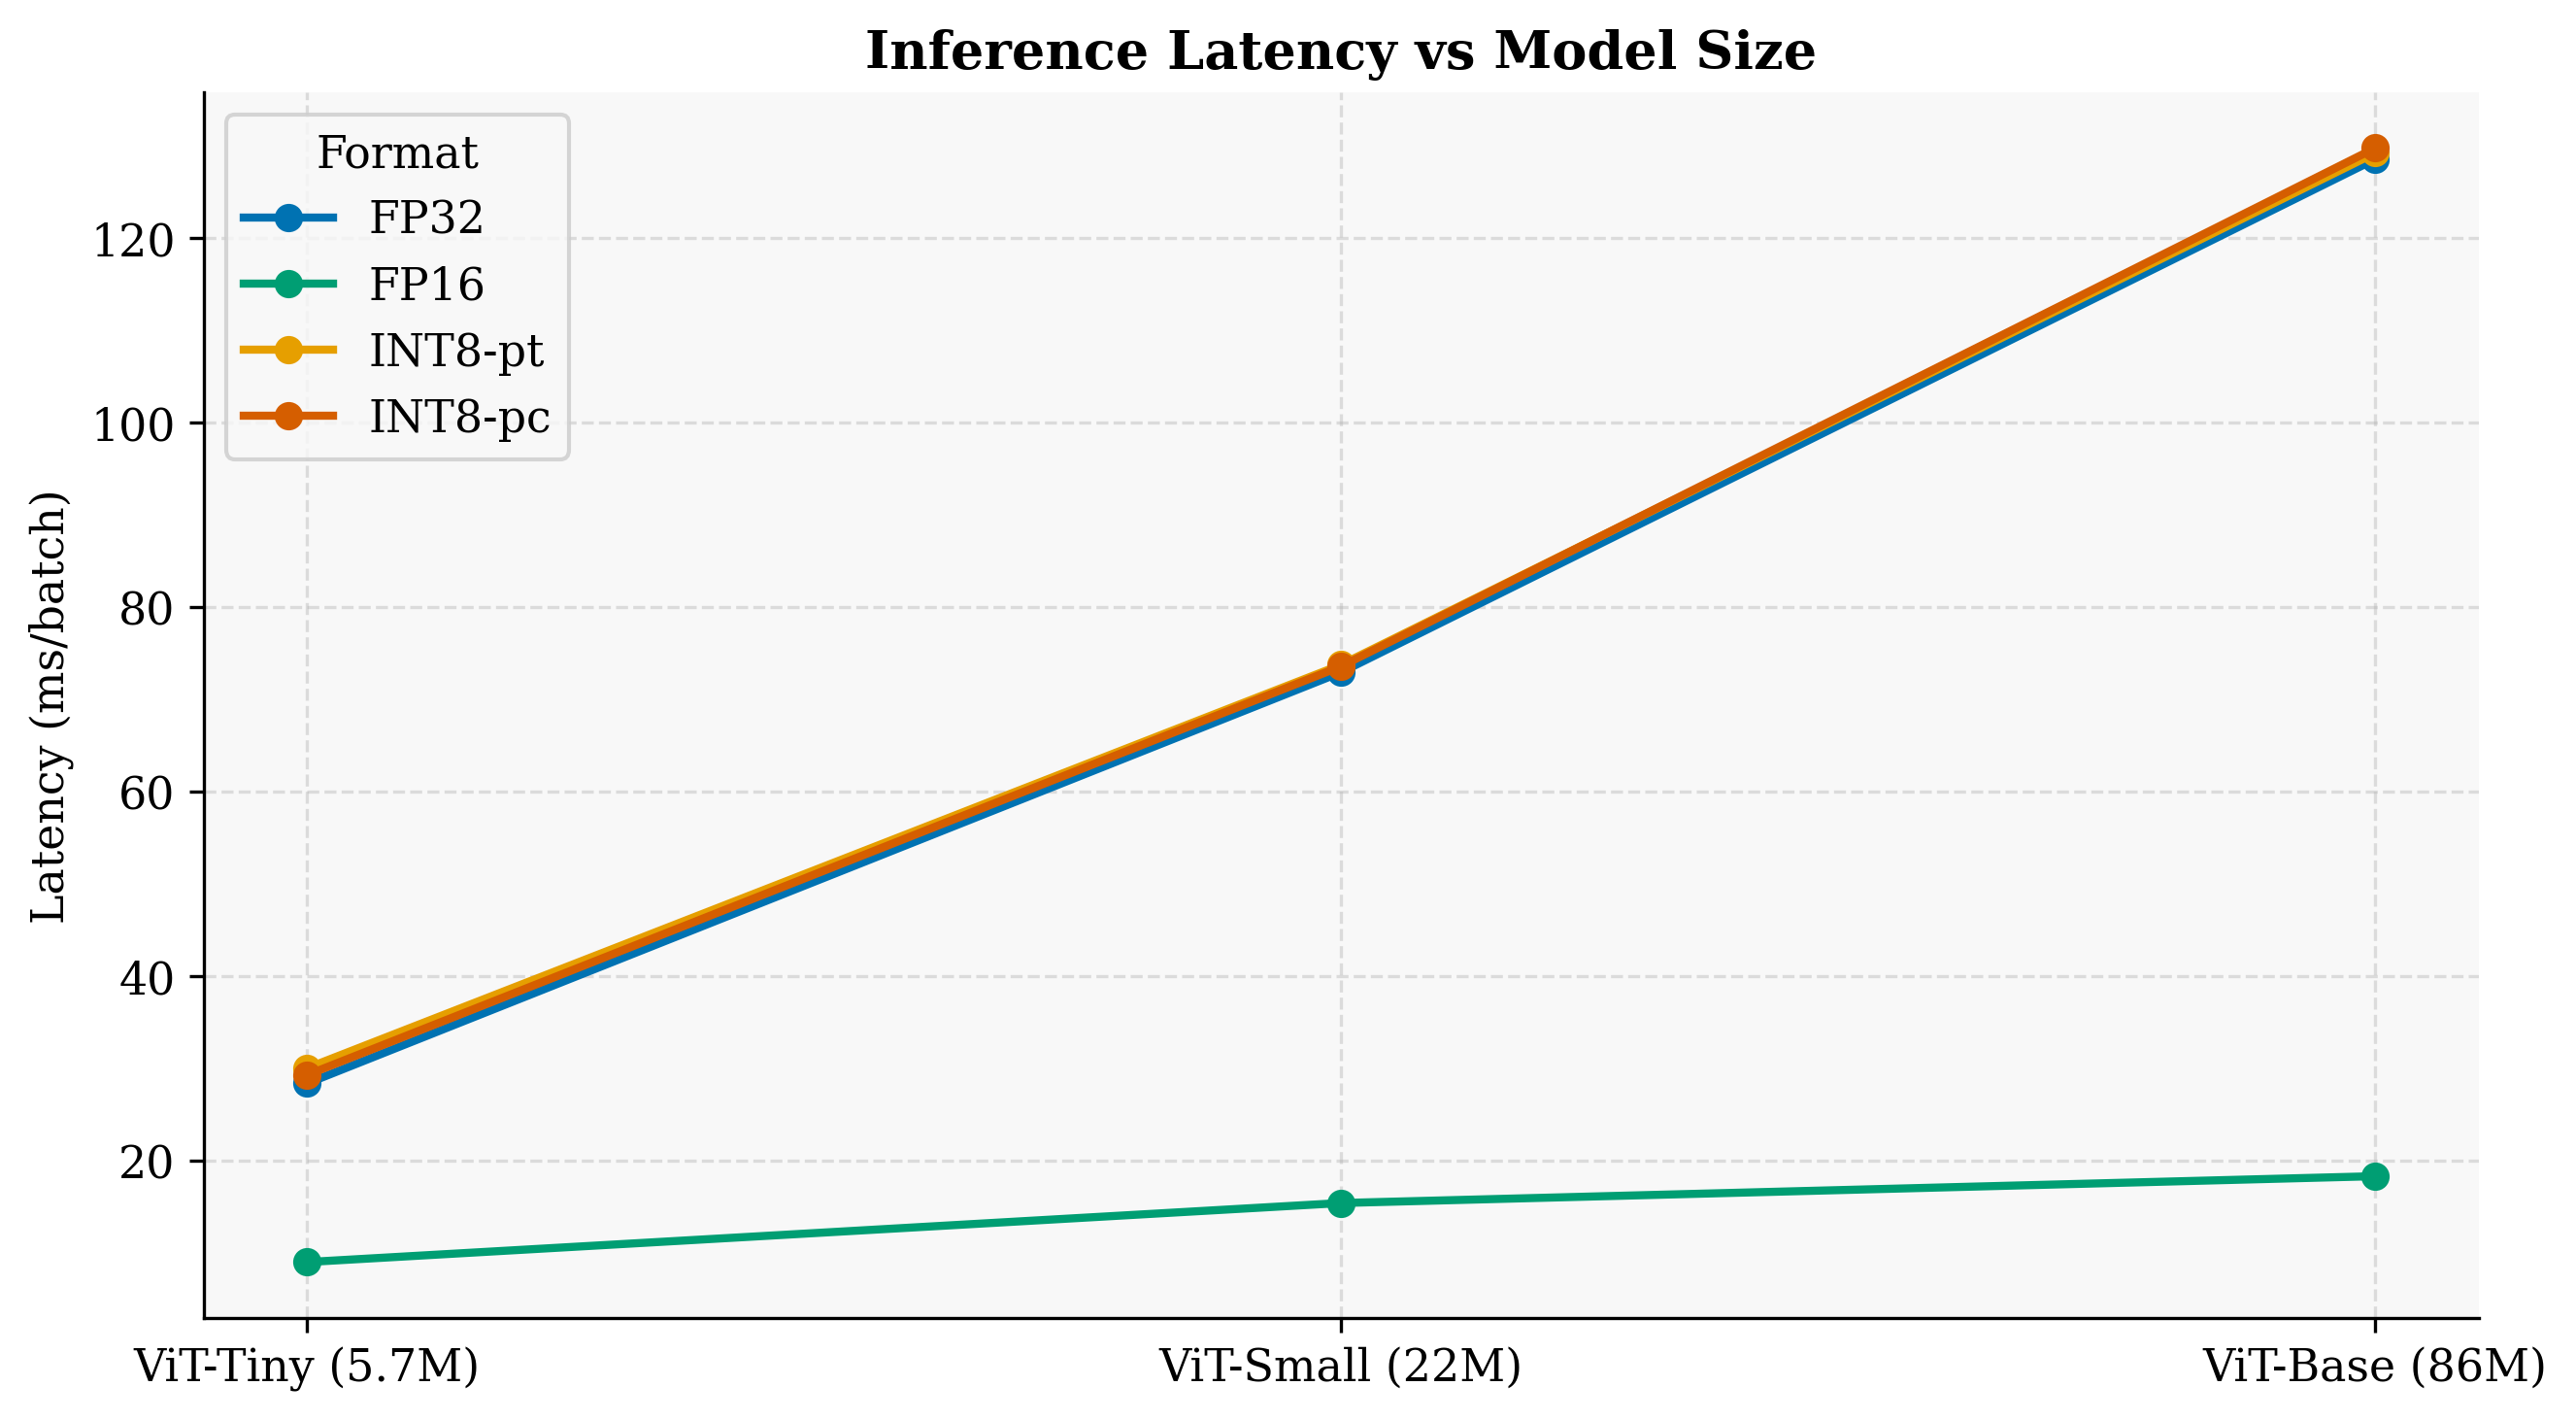

In [ ]:
from IPython.display import Image as IPImage, display
from pathlib import Path

for p in sorted(Path('results/Phase4/cross_model_comparison').glob('*.png')):
    print(f'\n--- {p.name} ---')
    display(IPImage(str(p)))

## 7. Salvare finala pe Drive

In [8]:
import shutil
shutil.copytree(
    '/content/ViT-FP8-experiments/results/Phase4',
    '/content/drive/MyDrive/vit_experiments/results/Phase4',
    dirs_exist_ok=True
)
print("Toate rezultatele salvate pe Drive!")

Toate rezultatele salvate pe Drive!
